# **KNN 3D Benchmark visual**

**Author:** Marek Šugár

Faculty of Mathematics, Physics and Informatics Comenius University in Bratislava

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error

# ML Stuff
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

In [2]:
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

In [3]:
performance_tracker = [[np.nan for j in range(3, 101)] for i in range(1, 101)]

for training_length in range(3, 20 + 1):
    for k in range(1, training_length + 1):
        MAPEs = []
        for ticker in ["ROP", "ENPH", "CDNS", "EPAM"]:
            Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-07' AND Date<='2022-12-31'", con=StockDataDatabase, parse_dates=["Date"])
            Stock_Data["Target"] = Stock_Data["Close"].shift(-1)
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            prediction_length = 1 # Days
            training_length = training_length

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                if window_start + training_length + prediction_length > len(TrainingDataFrame):
                    continue
                    
                scaler = StandardScaler()

                Training_Features = scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length])
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
            
                Test_Features = scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length])
                Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

                MODEL = KNeighborsRegressor(n_neighbors=k)

                MODEL.fit(Training_Features, Training_Target)
            
                prediction = MODEL.predict(Test_Features)

                MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        
        print(k, training_length, np.mean(MAPEs))
        performance_tracker[k][training_length] = np.mean(MAPEs)

1 3 2.0685971423253826
2 3 2.3301457051985466
3 3 2.595533775924508
1 4 2.0555421316751508
2 4 2.3349751276915645
3 4 2.607908507670727
4 4 2.8658668402615373
1 5 2.056078168095274
2 5 2.33408694066182
3 5 2.6040789944843854
4 5 2.872374877017385
5 5 3.1225146564542414
1 6 2.057996362596557
2 6 2.3234188053954625
3 6 2.6020136610962186
4 6 2.8822036757141745
5 6 3.126694980638351
6 6 3.3635245752102696
1 7 2.0585101995617303
2 7 2.320054795306327
3 7 2.6019902869284186
4 7 2.8843391625285117
5 7 3.131211214624159
6 7 3.376076048858854
7 7 3.5900639607310136
1 8 2.0597673544202073
2 8 2.3222792778211248
3 8 2.607729350767894
4 8 2.8857923447933325
5 8 3.129460196673233
6 8 3.3783718020553106
7 8 3.5931815413110813
8 8 3.8140359112867173
1 9 2.0603388264562756
2 9 2.322365204203647
3 9 2.6069078507645886
4 9 2.8849325019432275
5 9 3.1393138631654094
6 9 3.3777852694142694
7 9 3.5995654209757846
8 9 3.815633132465153
9 9 4.022339626045667
1 10 2.0603231270662246
2 10 2.3210285600102623
3 

In [4]:
pt1 = [i[:20] for i in performance_tracker]

In [5]:
minimum = float("inf")
kde = (-1, -1)
for i in range(len(performance_tracker)):
    for j in range(len(performance_tracker[i])):
        if performance_tracker[i][j] < minimum:
            minimum = performance_tracker[i][j]
            # k, TL
            kde = (i, j)

kde


(1, 4)

Text(50.722222222222214, 0.5, 'Number of k neighbours')

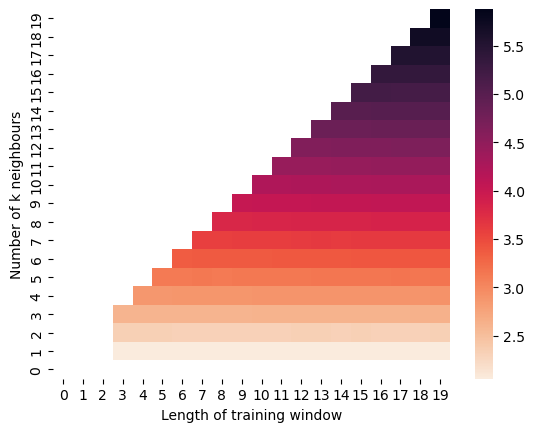

In [6]:
sns.heatmap(pt1[:20], cmap="rocket_r").invert_yaxis()

plt.xlabel("Length of training window")
plt.ylabel("Number of k neighbours")